### 1. Método de regressão descontínua

O conjunto de códigos abaixo replica o Capítulo 6, intitulado **"Método de regressão descontínua"**, do livro *Avaliação de Impacto na Prática*, segunda edição, dos autores Paul J. Gertler, Sebastián Martínez, Patrick Premand, Laura B. Rawlings e Christel M. J. Vermeersch. Este capítulo aborda a avaliação de impacto de políticas públicas por meio do método de regressão descontínua. Essa técnica é utilizada em programas que empregam um índice contínuo para determinar a elegibilidade, com um critério de elegibilidade claramente definido (ponto de corte), permitindo identificar quem é elegível e quem não é.. O livro, em formato digital, pode ser acessado gratuitamente no seguinte site: [Avaliação de Impacto na Prática](https://publications.iadb.org/pt/avaliacao-de-impacto-na-pratica-segunda-edicao).

### 2. Bibliotecas

In [260]:
# Manipulando os dados
import pandas as pd
import numpy as np

# Estatística
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações
import warnings
import os

### 3. Configurações

In [ ]:
# Definindo o diretorio
os.chdir("caminho_diretorio")

# Exibir todas as linhas e colunas
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

# Não exibir avisos
warnings.filterwarnings("ignore")

### 4. Manipulando os dados

In [262]:
# Importando os dados
dados = pd.read_stata("evaluation.dta")

# Primeiras observações
dados.head()

,locality_identifier,household_identifier,treatment_locality,promotion_locality,eligible,enrolled,enrolled_rp,poverty_index,round,health_expenditures,age_hh,age_sp,educ_hh,educ_sp,female_hh,indigenous,hhsize,dirtfloor,bathroom,land,hospital_distance,hospital
0,26.0,5.0,1.0,1.0,1.0,1.0,1.0,55.950542,0.0,15.185455,24.0,23.0,0.0,6.0,0.0,0.0,4.0,1,0,1,124.819966,0.0
1,26.0,5.0,1.0,1.0,1.0,1.0,1.0,55.950542,1.0,19.580902,25.0,24.0,0.0,6.0,0.0,0.0,4.0,1,0,1,124.819966,0.0
2,26.0,11.0,1.0,1.0,1.0,1.0,0.0,46.058731,0.0,13.076257,30.0,26.0,4.0,0.0,0.0,0.0,6.0,1,0,2,124.819966,0.0
3,26.0,11.0,1.0,1.0,1.0,1.0,0.0,46.058731,1.0,2.398854,31.0,27.0,4.0,0.0,0.0,0.0,6.0,1,0,2,124.819966,1.0
4,26.0,13.0,1.0,1.0,1.0,1.0,0.0,54.095825,1.0,0.000000,59.0,57.0,0.0,0.0,0.0,0.0,6.0,1,0,4,124.819966,1.0


In [263]:
# Formato dos dados
dados.shape

(19827, 22)

In [267]:
# Informaçoes sobre o df
#dados.info()

In [265]:
# Verificando se há dados faltantes. 
#dados.isna().sum().sort_values(ascending=False)

In [266]:
# estatísticas das variáveis
#dados.describe().T

### 5. Visualização

Contexto: Depois de realizar mais algumas investigações sobre o projeto do HISP, você descobre que, além de selecionar aleatoriamente os povoados que
serão submetidos ao tratamento, as autoridades direcionaram o programa para famílias de baixa renda utilizando a linha de pobreza nacional. A linha de pobreza se baseia em um índice de pobreza que atribui a cada família do país uma pontuação entre 20 e 100 com base em seus ativos, condições habitacionais e estrutura sociodemográfica. A linha de pobreza foi oficialmente fixada em 58. Isso significa que todas as famílias com uma pontuação de 58 ou menor são classificadas como pobres, e todas as famílias com uma pontuação superior a 58 são consideradas não pobres. Mesmo nos povoados de tratamento, apenas as famílias pobres são elegíveis para se inscrever no HISP. Seu conjunto de dados inclui informações sobre as famílias pobres e não pobres dos povoados de tratamento.

##### 5.1 Densidade das famílias , por índice de pobreza na linha de base

Verificando evidências de manipulação ao analisar a densidade do índice de elegibilidade e plotar a distribuição das famílias conforme o índice de pobreza da linha de base.

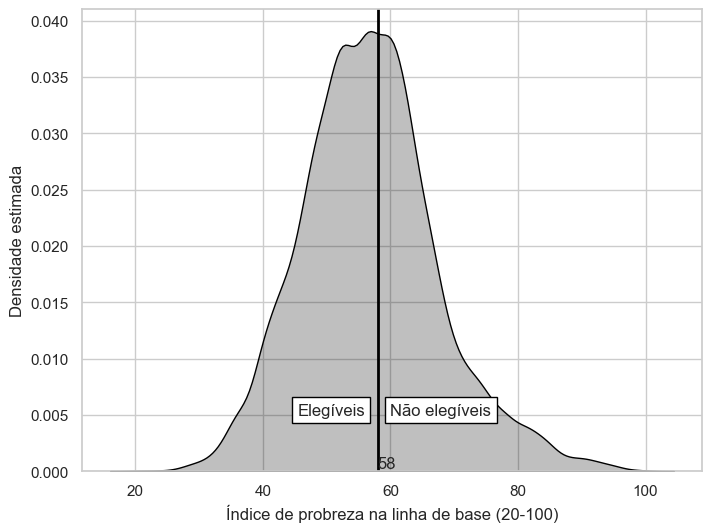

In [268]:
# Criando o gráfico de densidade
plt.figure(figsize=(8, 6))
sns.kdeplot(dados['poverty_index'], fill=True, color="black", bw_adjust=1)

# Adicionando linhas de referência e textos
plt.axvline(x=58, color="black", linestyle="-", linewidth=2)
plt.text(60, 0.005, "Não elegíveis", ha='left', bbox=dict(facecolor='white', edgecolor='black'))
plt.text(56, 0.005, "Elegíveis", ha='right', bbox=dict(facecolor='white', edgecolor='black'))
plt.text(58, 0, "58", ha='left', va='bottom')

# Configurações do gráfico
plt.title("")
plt.xlabel("Índice de probreza na linha de base (20-100)")
plt.ylabel("Densidade estimada")
plt.grid(True)
plt.show()

In [131]:
#dados.sort_values(by='poverty_index', ascending=True).head(10)

##### 5.2 Analisando se há algum tipo de manipulação 

Verificando se as famílias respeitaram sua alocação aos grupos de controle e de tratamento. Verificando visualmente se são cumpridores ou não cumpridores

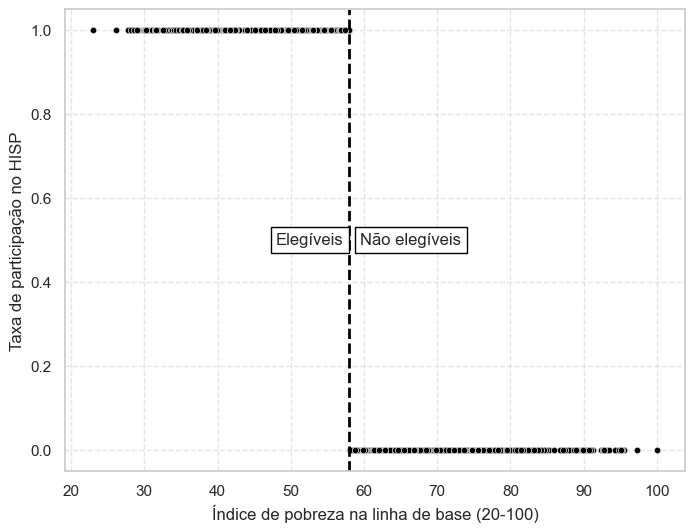

In [269]:
# Filtrar apenas treatment_locality == 1
df_filtered = dados[dados['treatment_locality'] == 1]

# Criar o gráfico de dispersão
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df_filtered['poverty_index'], y=df_filtered['enrolled'], color='black', s=20)

# Adicionar linha de corte
plt.axvline(x=58, color='black', linestyle='--', linewidth=2)

# Adicionar textos explicativos
plt.text(59.5, 0.5, "Não elegíveis", verticalalignment='center', bbox=dict(facecolor='white', edgecolor='black'))
plt.text(48, 0.5, "Elegíveis", verticalalignment='center', bbox=dict(facecolor='white', edgecolor='black'))

# Configurar rótulos e título
plt.xlabel("Índice de pobreza na linha de base (20-100)")
plt.ylabel("Taxa de participação no HISP")
plt.title("")
plt.grid(True, linestyle="--", alpha=0.5)

# Exibir o gráfico
plt.show()

##### 5.3 Análise preliminar se o programa diminui as despesas com saúde das famílias. Apenas uma visualização inicial, sem controle algum.

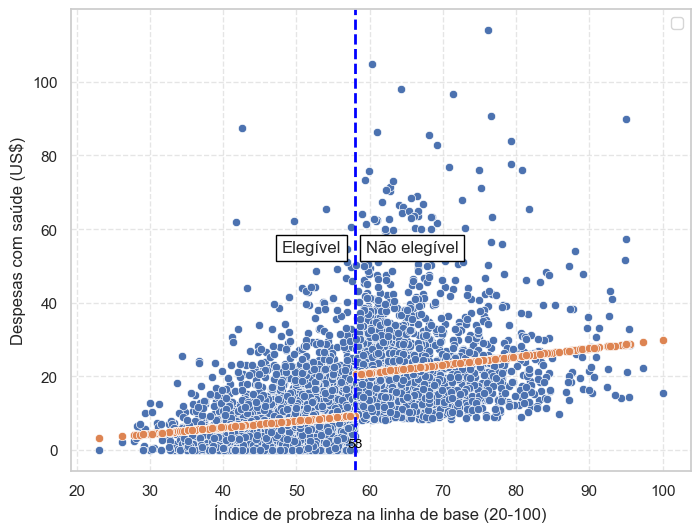

In [270]:
dados = dados[dados['treatment_locality'] == 1]

# Normalizar o índice de pobreza em relação ao ponto de corte (58)
dados['poverty_index_left'] = np.where(dados['poverty_index'] <= 58, dados['poverty_index'] - 58, 0)
dados['poverty_index_right'] = np.where(dados['poverty_index'] > 58, dados['poverty_index'] - 58, 0)

# Filtrar apenas round == 1
df_filtered = dados[dados['round'] == 1]

# Regressão linear para prever gastos com saúde
X = df_filtered[['poverty_index_left', 'poverty_index_right', 'eligible']]
X = sm.add_constant(X)  # Adiciona constante ao modelo
y = df_filtered['health_expenditures']
model = sm.OLS(y, X).fit()
df_filtered['he_pred1'] = model.predict(X)

# Criar o gráfico
plt.figure(figsize=(8, 6))

# Gráfico de dispersão dos dados reais
sns.scatterplot(x=df_filtered['poverty_index'], y=df_filtered['health_expenditures'])

# Gráfico da previsão do modelo
sns.scatterplot(x=df_filtered['poverty_index'], y=df_filtered['he_pred1'])

# Adicionar linha de corte
plt.axvline(x=58, color='blue', linestyle='--', linewidth=2)


# Adicionar textos explicativos
plt.text(59.5, 55, "Não elegível", verticalalignment='center', bbox=dict(facecolor='white', edgecolor='black'))
plt.text(48, 55, "Elegível", verticalalignment='center', bbox=dict(facecolor='white', edgecolor='black'))
plt.text(58, 0, "58", verticalalignment='bottom', horizontalalignment='center', fontsize=10, color="black")

# Configurar rótulos e título
plt.xlabel("Índice de probreza na linha de base (20-100)")
plt.ylabel("Despesas com saúde (US$)")
plt.title("")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)

# Exibir o gráfico
plt.show()

### 6. Regressão

In [271]:
# Importando os dados novamente
df = pd.read_stata('evaluation.dta')
df.head()

,locality_identifier,household_identifier,treatment_locality,promotion_locality,eligible,enrolled,enrolled_rp,poverty_index,round,health_expenditures,age_hh,age_sp,educ_hh,educ_sp,female_hh,indigenous,hhsize,dirtfloor,bathroom,land,hospital_distance,hospital
0,26.0,5.0,1.0,1.0,1.0,1.0,1.0,55.950542,0.0,15.185455,24.0,23.0,0.0,6.0,0.0,0.0,4.0,1,0,1,124.819966,0.0
1,26.0,5.0,1.0,1.0,1.0,1.0,1.0,55.950542,1.0,19.580902,25.0,24.0,0.0,6.0,0.0,0.0,4.0,1,0,1,124.819966,0.0
2,26.0,11.0,1.0,1.0,1.0,1.0,0.0,46.058731,0.0,13.076257,30.0,26.0,4.0,0.0,0.0,0.0,6.0,1,0,2,124.819966,0.0
3,26.0,11.0,1.0,1.0,1.0,1.0,0.0,46.058731,1.0,2.398854,31.0,27.0,4.0,0.0,0.0,0.0,6.0,1,0,2,124.819966,1.0
4,26.0,13.0,1.0,1.0,1.0,1.0,0.0,54.095825,1.0,0.000000,59.0,57.0,0.0,0.0,0.0,0.0,6.0,1,0,4,124.819966,1.0


In [272]:
df.shape

(19827, 22)

In [273]:
# Selecionando apenas as linhas em que treatment_locality é igual a 1
df_treatment = df[df['treatment_locality'] == 1]

# Centrando os dados
df_treatment['poverty_index_c0'] = df_treatment['poverty_index'] - 58

# Selecionando apenas as linhas em que round é igual a 1
df_treatment = df_treatment[df_treatment['round'] == 1]

# Criando uma variável de interação
df_treatment['poverty_index_enrolled'] = df_treatment['poverty_index_c0'] * df_treatment['enrolled']

In [274]:
# Definindo a fórmula para o modelo
formula = 'health_expenditures ~ poverty_index_c0 * enrolled + age_hh + age_sp + educ_hh + educ_sp + female_hh + indigenous + hhsize + dirtfloor + bathroom + land + hospital_distance'

# Ajustando o modelo de regressão robusta
model = smf.ols(formula=formula, data=df_treatment).fit(cov_type='HC3')  # HC3 para robustez

# Exibindo o resumo do modelo
print(model.summary())

                             OLS Regression Results                            
Dep. Variable:     health_expenditures   R-squared:                       0.458
Model:                             OLS   Adj. R-squared:                  0.457
Method:                  Least Squares   F-statistic:                     213.0
Date:                 Tue, 25 Feb 2025   Prob (F-statistic):               0.00
Time:                         16:29:29   Log-Likelihood:                -18006.
No. Observations:                 4960   AIC:                         3.604e+04
Df Residuals:                     4945   BIC:                         3.614e+04
Df Model:                           14                                         
Covariance Type:                   HC3                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept   

O Impacto estimado pelo programa é dado pela variável `enrolled`, ela mostra que o impacto do programa na despesas cm saúde das famílias participantes foi de -US$ 9,028. Ressalta-se que esta estimativa não é a mais adequada visto que não definimos uma bandwidth.